In [1]:
# ================================================
# TITANIC SURVIVAL PREDICTION - CLASSIFICATION
# Beginner Friendly - Full Pipeline
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For warnings
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")



## 1. Load the Data

In [2]:
# Load dataset
df = pd.read_csv('Titanic.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploratory Data Analysis (EDA) & Visualization

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked    

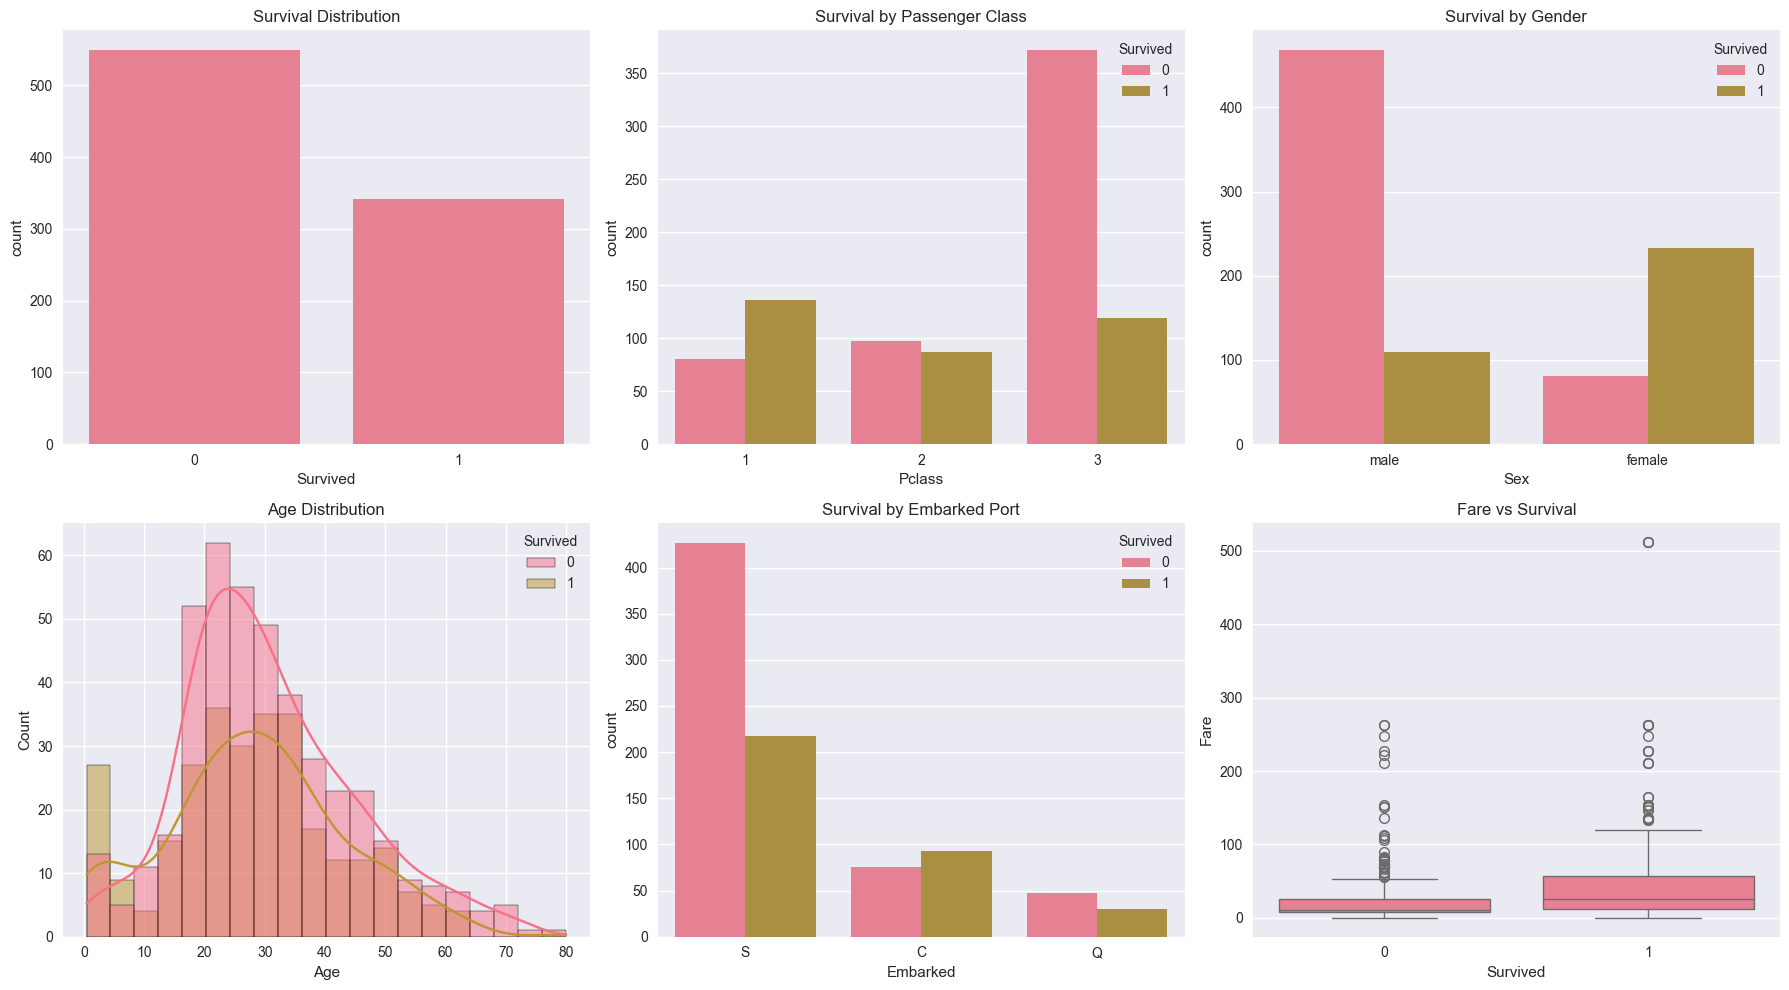

In [3]:
# Basic information
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nSurvival Rate:\n", df['Survived'].value_counts(normalize=True) * 100)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=df, x='Survived', ax=axes[0,0])
axes[0,0].set_title('Survival Distribution')

sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0,1])
axes[0,1].set_title('Survival by Passenger Class')

sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0,2])
axes[0,2].set_title('Survival by Gender')

sns.histplot(data=df, x='Age', hue='Survived', kde=True, ax=axes[1,0])
axes[1,0].set_title('Age Distribution')

sns.countplot(data=df, x='Embarked', hue='Survived', ax=axes[1,1])
axes[1,1].set_title('Survival by Embarked Port')

sns.boxplot(data=df, x='Survived', y='Fare', ax=axes[1,2])
axes[1,2].set_title('Fare vs Survival')

plt.tight_layout()
plt.show()

## 3. Data Processing / Cleaning

In [4]:
# Make a copy
data = df.copy()

# Fill missing values
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Fare'] = data['Fare'].fillna(data['Fare'].median())

# Drop columns not needed for modeling
data = data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Feature Engineering
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

# Encode categorical variables
data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)

print("✅ Data cleaned and features engineered!")
print("Final columns:", data.columns.tolist())

✅ Data cleaned and features engineered!
Final columns: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S']


## 4. Data Splitting

In [5]:
from sklearn.model_selection import train_test_split

X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


## 5. Feature Scaling (Important for KNN & SVM)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Model Building & Evaluation

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', random_state=42)
}

results = []

for name, model in models.items():
    # Use scaled data for KNN and SVM
    if name in ["KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    results.append({"Model": name, "Accuracy": round(acc*100, 2)})
    
    print(f"\n🔹 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, pred))

# Summary
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n📊 Model Performance Summary:")
print(results_df)


🔹 Logistic Regression Accuracy: 0.7989
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179


🔹 Decision Tree Accuracy: 0.7598
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       110
           1       0.74      0.58      0.65        69

    accuracy                           0.76       179
   macro avg       0.75      0.73      0.73       179
weighted avg       0.76      0.76      0.75       179


🔹 Random Forest Accuracy: 0.8212
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0

## 7. Test Model with New Sample Data (Manual Input)

In [8]:
# Best model (usually Random Forest)
best_model = RandomForestClassifier(random_state=42, n_estimators=100)
best_model.fit(X_train, y_train)   # Train on full training data

# Example: Create a new passenger
new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Age': [25],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [7.25],
    'FamilySize': [1],
    'IsAlone': [1],
    'Sex_male': [1],           # 1 = Male, 0 = Female
    'Embarked_Q': [0],
    'Embarked_S': [1]
})

# Make prediction
prediction = best_model.predict(new_passenger)
probability = best_model.predict_proba(new_passenger)

print("\n🎯 Prediction for new passenger:")
print("Survived" if prediction[0] == 1 else "Did NOT Survive")
print(f"Confidence: {max(probability[0])*100:.1f}%")


🎯 Prediction for new passenger:
Did NOT Survive
Confidence: 97.0%


## 8. SAVE THE BEST MODEL

In [10]:
# ============================
# 8. SAVE THE BEST MODEL
# ============================

import joblib
import os

# Train the best performing model on full training data
best_model = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)
best_model.fit(X_train, y_train)

# Create directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save model and scaler
joblib.dump(best_model, 'models/titanic_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Model and Scaler saved successfully in 'models/' folder!")

# Optional: Save feature names for Streamlit
joblib.dump(X.columns.tolist(), 'models/feature_names.pkl')
print("Feature names saved!")

✅ Model and Scaler saved successfully in 'models/' folder!
Feature names saved!
